In [129]:
import ROOT
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as LogNorm
import matplotlib.ticker as ticker
import math
import pandas as pd

#plt.rcParams['figure.figsize'] = [8, 8]

plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
tags = ['rbg_As', 'sim_As', '']
tFile_name = '../../BAND/subtracted_hists_f2_noNormError.root'
as_lims = ['1.15', '1.20', '1.30', '1.40', '1.50']
pT_vals = [.05, .07, .09, .1]
as_vals = [1.175, 1.25, 1.35, 1.45]


In [186]:
def makePlot(ax, As):
    dat = uproot.open(tFile_name)
    hists = [dat[f'rgb_As{As};1'],dat[f'sim_As{As};1'],dat[f'subtracted_As{As};1']]

    values = hists[0].values()#/hists[1].values()
    values[values == 0] = np.nan
    errors = hists[0].errors()
    

    print(values)
    xEdges = hists[0].axis(0).centers()

    #ax.set_tick_params(which='both', width=2, labelsize=14)
    #ax.set_tick_params(which='major', length=7, labelsize=14)
    #ax.set_tick_params(which='minor', length=4, labelsize=14)

    #ax.errorbar(xEdges-.003, values, errors, color='b', linestyle=' ', marker='o',label='RG-B')
    #ax.axhline(xmin=0, xmax=1, y=1, color='k', linestyle='--')
    as_labels = [as_lims[As], as_lims[As+1]]

    values = hists[2].values()#/hists[1].values()
    values[values == 0] = np.nan
    errors = hists[2].errors()
    ax.errorbar(xEdges, values, errors, color='r', linestyle=' ', marker='o',label=r'RG-B $-$ RG-A')
    ax.axhline(xmin=0, xmax=1, y=1, color='k', linestyle='--')
    #label_y_loc = 1.05*(np.max(values) +  errors[np.argmax(values)])
    ax.text( .3, 2.5, as_labels[0]+rf'$<\alpha_S<$'+as_labels[1],fontsize=18)
    ax.set_xlabel(r'$x^{\prime}$', fontsize = 20)
    ax.set_ylabel(r'$\mathcal{R}$', fontsize = 20)

#drawCut2D( axs[0], key )		
#setTitle2D( axs[0], key )


[1.14192102 1.         1.08607786 0.90754881 0.95453883 0.97065497
 1.16869164 1.0675804  1.13859296]
[1.05045535 1.         0.99612421 0.92777067 0.94778649 1.00357899
 1.10081077 1.20796004 1.28393571]
[1.13062835 1.         0.94712645 0.96295584 0.9961841  1.01000214
 1.34353047 1.62070898 2.00089154]
[1.30516164 1.         0.91851884 1.02687077 0.93092563 1.18078451
 1.31849839 1.53184178 1.56644114]


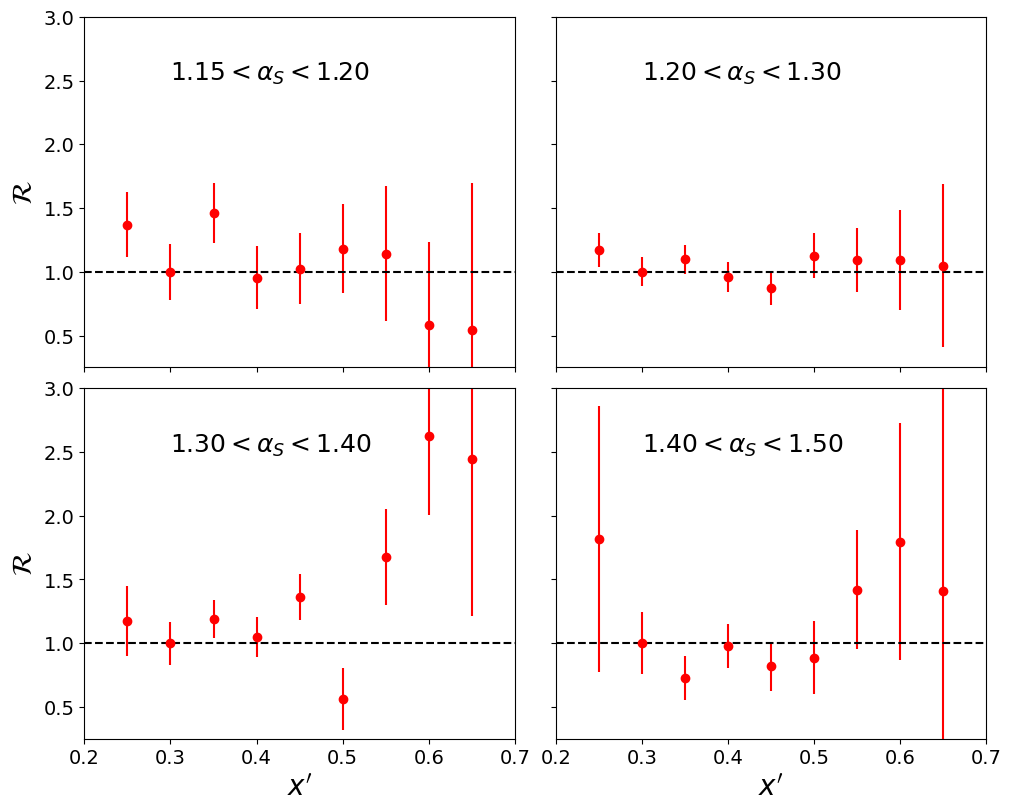

In [136]:
fig, axs = plt.subplots(2, 2, figsize=(10,8), layout='constrained', sharex=True, sharey=True)

for As in range(0,4):
    makePlot( axs[math.floor(As/2)][As%2], As)


#axs[0,0].legend(fontsize=18)
plt.xlim(.2, .7)
plt.ylim(0.25, 3)
for ax in axs.flat:
    ax.label_outer()

plt.savefig("test.pdf")


In [87]:
dat = uproot.open(tFile_name)
with open("../../f2n_offshell_marathon/exp_data/band_data_sub.txt", "w") as file:
    file.write("xP\tAs\tPt\tR\tdR\n")
    
    for bin in range(4):
        hists = [dat[f'rgb_As{bin};1'],dat[f'sim_As{bin};1'],dat[f'subtracted_As{bin};1']]

        values = hists[2].values()#/hists[1].values()
        #values[values == 0] = np.nan
        errors = hists[2].errors()
        As = as_vals[bin]
        pT = pT_vals[bin]

        for point in range(np.size(values)):
            rat = values[point]
            if np.isnan(rat):
                continue
            err = errors[point]
            xEdges = hists[2].axis(0).centers()
            xp = xEdges[point]

            file.write(f"{xp:.6f}\t{As:.6f}\t{pT:.6f}\t{rat:.6f}\t{err:.6f}\n")
    


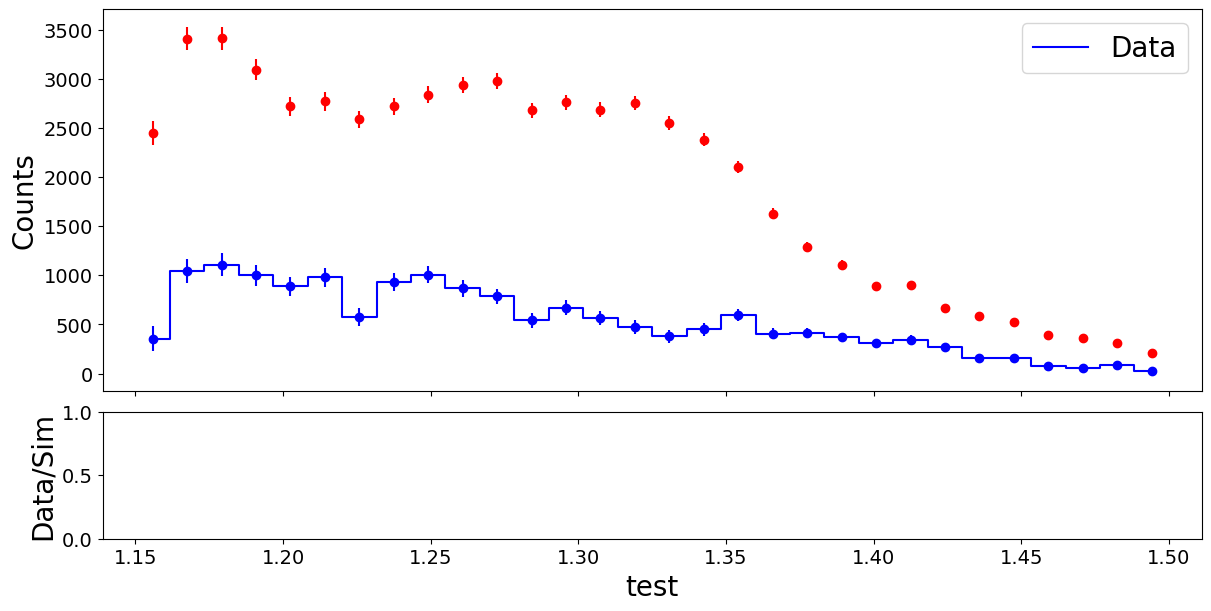

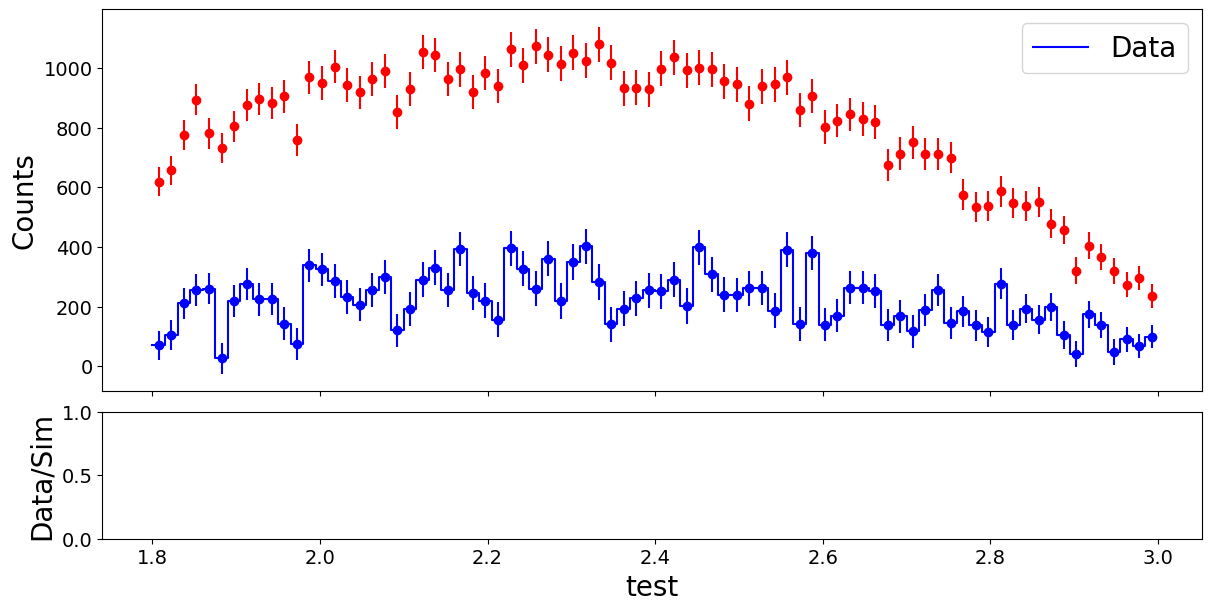

In [213]:
vNames=['As','Wp']
vLabels=[r'$W^{\prime}$', r'$\alpha_S$']
dat = uproot.open('../../BAND/Xp_As_rga_rgb_data_sim_large_inclFit_noNormError.root')

bac_norm_rgb = np.sum(dat[f'hToF_rgb_bg;1'].values())
#print(bac_norm_rgb)
for var in vNames:
    fig, ax = plt.subplots(2, 1, figsize=(12,6), height_ratios=[3,1], sharex='col', layout='constrained')
    sim = uproot.open('../../BAND_final_plots/comps/data_sim_no_min_angle.root')
    hists = [dat[f'h{var}_rgb_sig;1'],dat[f'h{var}_rgb_bg;1'],dat[f'h{var}_rga_sig;1'],dat[f'h{var}_rga_bg;1'],sim[f'h{var}_0_Simulation;1']]
    values_sig = hists[0].values()#/hists[1].values()
    values_sig[values_sig == 0] = np.nan
    errors_sig = hists[0].errors()
    
    values_bac = hists[1].values()#/hists[1].values()
    values_bac[values_bac == 0] = np.nan
    errors_bac = hists[1].errors()

    values_sig_rga = hists[2].values()#/hists[1].values()
    values_sig_rga[values_sig_rga == 0] = np.nan
    errors_sig_rga = hists[2].errors()
    
    values_bac_rga = hists[3].values()#/hists[1].values()
    values_bac_rga[values_bac_rga == 0] = np.nan
    errors_bac_rga = hists[3].errors()

    xEdges = hists[0].axis(0).centers()


    ax[0].errorbar(xEdges, values_sig-values_bac, errors_sig, color='r', linestyle=' ', marker='o')
    ax[0].errorbar(xEdges, values_sig-values_bac-(values_sig_rga - values_bac_rga), errors_sig, color='b', linestyle=' ', marker='o')
    
    ax[0].step(xEdges, values_sig-values_bac-(values_sig_rga - values_bac_rga), color='b',  marker=' ', where='mid', label='Data')
    #ax[0].step(xEdges, values_sim, color='r',  marker=' ', where='mid',label='BG')
    #
    
    #ratio = values_sig/values_sim
    #ratio_err =  ratio*np.sqrt( (errors_sig/values_sig)**2 + (errors_sim/values_sim)**2 )
    #ratio_err[ratio_err<=0] = np.nan
    #ax[1].errorbar(xEdges, ratio, ratio_err, color='k', linestyle=' ', marker='o')
    #ax[1].axhline(xmin=0, xmax=1, y=1, color='grey', linestyle='--')
    

   
    ax[1].set_xlabel('test', fontsize = 20)
    ax[0].set_ylabel(r'Counts', fontsize = 20)
    ax[1].set_ylabel('Data/Sim', fontsize=20)

    ax[0].legend(fontsize=20)

Text(0, 0.5, 'Counts')

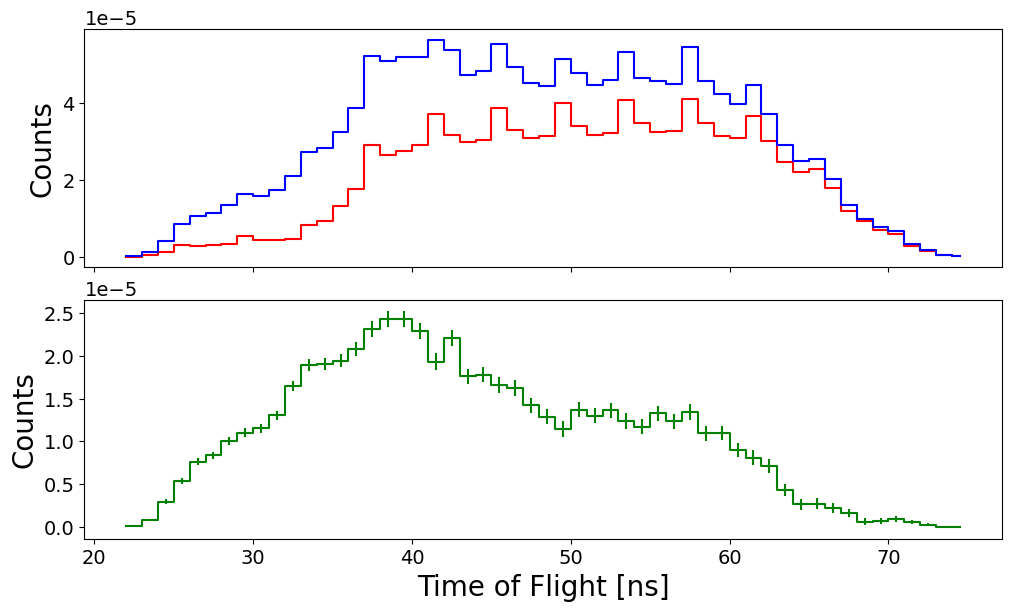

In [164]:
vNames=['Wp','As']
vLabels=[r'$W^{\prime}$', r'$\alpha_S$']
dat = uproot.open('../../BAND_final_plots/comps/data_sim_no_min_angle.root')#E_10.2/binned_E.root')


fig, ax = plt.subplots(2, 1, figsize=(10,6), height_ratios=[1,1], sharex='col', layout='constrained')
hists = [dat[f'hTOF_0_Data;1'],dat[f'hTOF_0_Background;1']]

values_sig = hists[0].values()#/hists[1].values()
values_sig[values_sig == 0] = np.nan
errors_sig = hists[0].errors()

values_back = hists[1].values()#/hists[1].values()
values_back[values_back == 0] = np.nan
errors_back = hists[1].errors()

values_sum = values_sig + values_back
errors_sum = np.sqrt(errors_back**2 + errors_sig**2)

xEdges = hists[0].axis(0).centers()

ax[1].errorbar(xEdges, values_sig, errors_sig, color='g', linestyle=' ', marker=' ', label='Signal')
ax[0].errorbar(xEdges, values_back, errors_back,  color='r', linestyle=' ', marker=' ')
ax[0].errorbar(xEdges, values_sum, errors_back,  color='b', linestyle=' ', marker=' ')
ax[0].step(xEdges, values_back,  where='mid', color='r', label='Background')
ax[0].step(xEdges, values_sum,  where='mid', color='b', label='Signal + Background')
ax[1].step(xEdges, values_sig, where='mid', color='g', label='Signal')

#



ax[1].set_xlabel(r'Time of Flight [ns]', fontsize = 20)
ax[0].set_ylabel(r'Counts', fontsize = 20)
ax[1].set_ylabel(r'Counts', fontsize = 20)

#ax[1].legend(fontsize=20)